## Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. A

In [18]:
img = cv2.imread('Nama.jpeg') 
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [19]:
R = rgb[:,:,0]
G = rgb[:,:,1]
B = rgb[:,:,2]

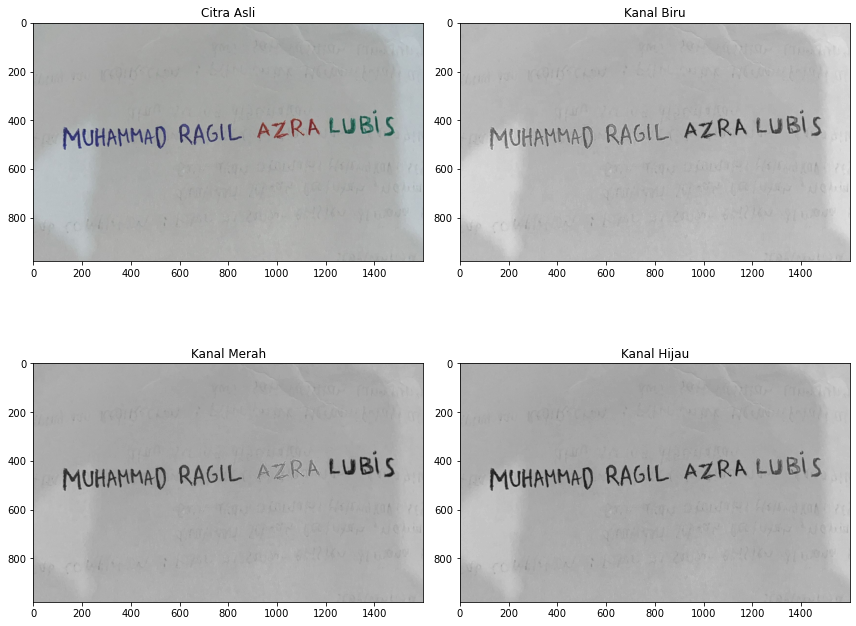

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].imshow(rgb)
axs[0, 0].set_title("Citra Asli")

axs[0, 1].imshow(B, cmap='gray')
axs[0, 1].set_title("Kanal Biru")

axs[1, 0].imshow(R, cmap='gray')
axs[1, 0].set_title("Kanal Merah")

axs[1, 1].imshow(G, cmap='gray')
axs[1, 1].set_title("Kanal Hijau")

plt.tight_layout()
plt.show()

## 1. C

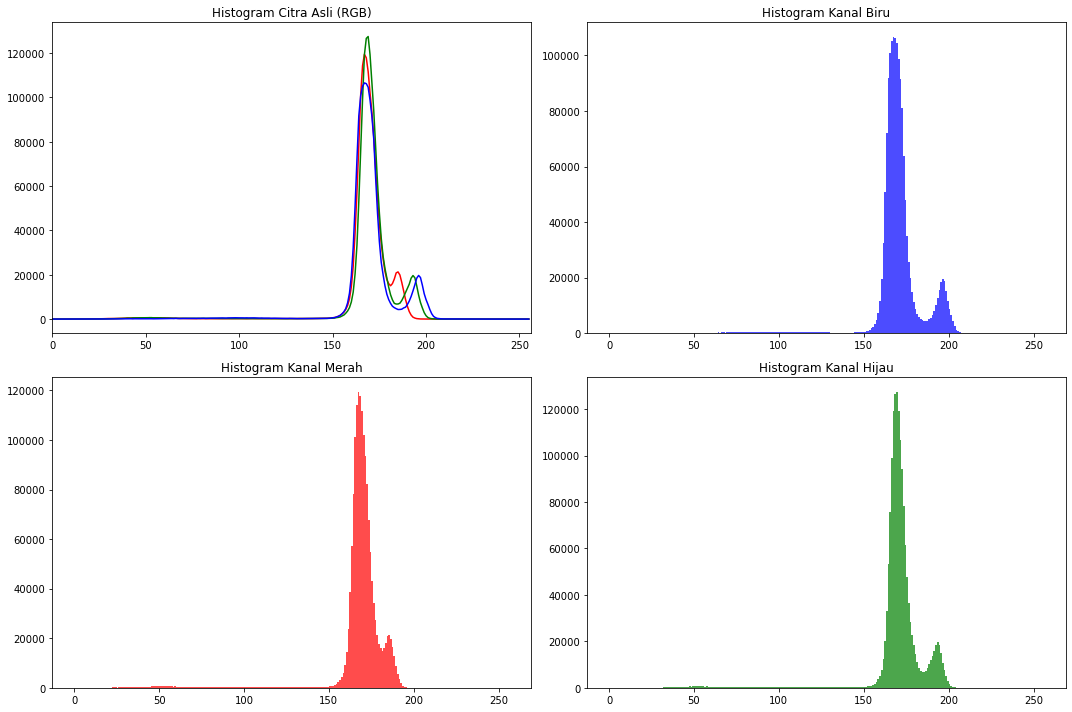

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs[0, 0].set_title("Histogram Citra Asli (RGB)")
color = ('r', 'g', 'b')
for i, col in enumerate(color):
    hist = cv2.calcHist([rgb], [i], None, [256], [0, 256])
    axs[0, 0].plot(hist, color=col)
    axs[0, 0].set_xlim([0, 256])

# Histogram Kanal Biru
axs[0, 1].hist(B.ravel(), 256, [0, 256], color='blue', alpha=0.7)
axs[0, 1].set_title("Histogram Kanal Biru")

# Histogram Kanal Merah
axs[1, 0].hist(R.ravel(), 256, [0, 256], color='red', alpha=0.7)
axs[1, 0].set_title("Histogram Kanal Merah")

# Histogram Kanal Hijau
axs[1, 1].hist(G.ravel(), 256, [0, 256], color='green', alpha=0.7)
axs[1, 1].set_title("Histogram Kanal Hijau")

plt.tight_layout()
plt.show()

## AMBANG BATAS

In [38]:
hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

# Menentukan rentang ambang batas HSV untuk tiap warna
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])

lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])

lower_green = np.array([35, 40, 40]) 
upper_green = np.array([90, 255, 255])

# Proses Masking berdasarkan nilai ambang batas
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask_red = cv2.add(mask_red1, mask_red2) 
mask_green = cv2.inRange(hsv, lower_green, upper_green)

## Menampilkan Hasil

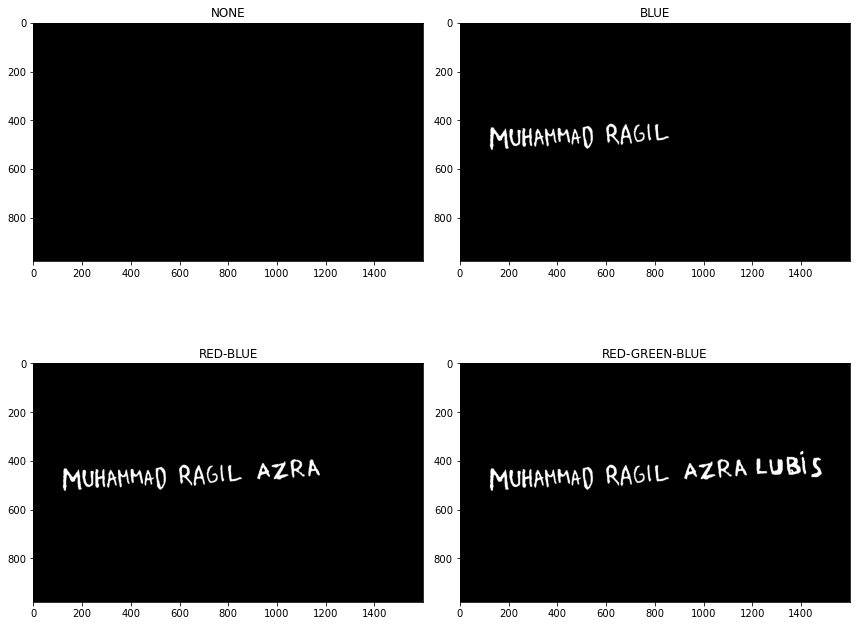

In [39]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].imshow(np.zeros_like(mask_blue), cmap='gray')
axs[0, 0].set_title("NONE")
axs[0, 1].imshow(mask_blue, cmap='gray')
axs[0, 1].set_title("BLUE")
axs[1, 0].imshow(cv2.bitwise_or(mask_red, mask_blue), cmap='gray')
axs[1, 0].set_title("RED-BLUE")
axs[1, 1].imshow(cv2.bitwise_or(cv2.bitwise_or(mask_red, mask_blue), mask_green), cmap='gray')
axs[1, 1].set_title("RED-GREEN-BLUE")
plt.tight_layout()
plt.show()